# Student Academic Performance Prediction Using KNN

**Course:** BMCS2203 Artificial Intelligence  
**Algorithm:** K-Nearest Neighbors (KNN)  
**Student Name:** Lim Jun Hao  
**Student ID:** 26WMR12877

### Project objective

This notebook develops a supervised machine learning model that predicts student performance as **Low**, **Medium**, or **High** using academic, personal, family, and school-related factors.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("StudentPerformanceFactors.csv")

In [3]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 6607
Number of columns: 20


In [5]:
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

## 1. Dataset overview

The Student Performance Factors dataset contains:

- **6,607 student records**
- **20 original attributes**
- Academic, personal, family, and school-related factors

Each row represents one student, and each column represents one factor.

### Missing values

| Attribute | Missing values |
|---|---:|
| Teacher_Quality | 78 |
| Parental_Education_Level | 90 |
| Distance_from_Home | 67 |

The missing values must be handled before model training because KNN cannot calculate distances when input values are missing.


In [6]:
print("Number of duplicated rows:", df.duplicated().sum())

Number of duplicated rows: 0


In [7]:
print("Minimum exam score:", df["Exam_Score"].min())
print("Maximum exam score:", df["Exam_Score"].max())
print("Average exam score:", df["Exam_Score"].mean())

Minimum exam score: 55
Maximum exam score: 101
Average exam score: 67.23565914938702


In [8]:
df["Performance"] = pd.cut(
    df["Exam_Score"],
    bins=[-np.inf, 64, 69, np.inf],
    labels=["Low", "Medium", "High"],
    ordered=True
)

In [9]:
df.loc[
    df["Exam_Score"].isin([64, 65, 69, 70]),
    ["Exam_Score", "Performance"]
].drop_duplicates().sort_values("Exam_Score")

,Exam_Score,Performance
15,64,Low
14,65,Medium
8,69,Medium
4,70,High


In [10]:
class_counts = df["Performance"].value_counts().reindex(
    ["Low", "Medium", "High"]
)

class_counts

Performance
Low       1452
Medium    3530
High      1625
Name: count, dtype: int64

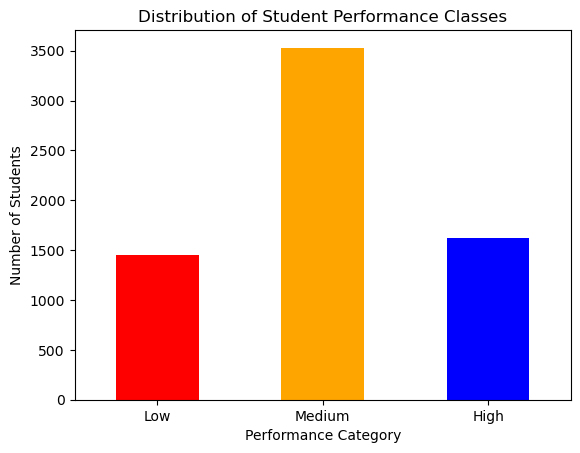

In [11]:
class_counts.plot(
    kind="bar",
    color=["red", "orange", "blue"]
)

plt.title("Distribution of Student Performance Classes")
plt.xlabel("Performance Category")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)
plt.show()

## 2. Target variable creation

The original `Exam_Score` is numerical. For this classification task, it was converted into three performance categories:

| Exam score | Performance class |
|---|---|
| Below 65 | Low |
| 65 to 69 | Medium |
| 70 or above | High |

The Medium class contains more records than the Low and High classes. Stratified splitting and class-sensitive evaluation metrics are therefore used later in the notebook.


In [12]:
X = df.drop(columns=["Exam_Score", "Performance"])
y = df["Performance"]

In [13]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Exam_Score in X:", "Exam_Score" in X.columns)
print("Performance in X:", "Performance" in X.columns)

X shape: (6607, 19)
y shape: (6607,)
Exam_Score in X: False
Performance in X: False


## 3. Feature and target separation

- `X` contains the input features used by the model.
- `y` contains the target class, `Performance`.

`Exam_Score` is removed from `X` because it was used to create `Performance`. Keeping it would give the model direct access to the answer and cause **target leakage**.


In [14]:
X.dtypes

Hours_Studied                  int64
Attendance                     int64
Parental_Involvement          object
Access_to_Resources           object
Extracurricular_Activities    object
Sleep_Hours                    int64
Previous_Scores                int64
Motivation_Level              object
Internet_Access               object
Tutoring_Sessions              int64
Family_Income                 object
Teacher_Quality               object
School_Type                   object
Peer_Influence                object
Physical_Activity              int64
Learning_Disabilities         object
Parental_Education_Level      object
Distance_from_Home            object
Gender                        object
dtype: object

In [15]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

print("\nNumber of numeric features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

Numeric features:
['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity']

Categorical features:
['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']

Number of numeric features: 6
Number of categorical features: 13


In [16]:
for column in categorical_features:
    print(column, ":", df[column].dropna().unique())

Parental_Involvement : ['Low' 'Medium' 'High']
Access_to_Resources : ['High' 'Medium' 'Low']
Extracurricular_Activities : ['No' 'Yes']
Motivation_Level : ['Low' 'Medium' 'High']
Internet_Access : ['Yes' 'No']
Family_Income : ['Low' 'Medium' 'High']
Teacher_Quality : ['Medium' 'High' 'Low']
School_Type : ['Public' 'Private']
Peer_Influence : ['Positive' 'Negative' 'Neutral']
Learning_Disabilities : ['No' 'Yes']
Parental_Education_Level : ['High School' 'College' 'Postgraduate']
Distance_from_Home : ['Near' 'Moderate' 'Far']
Gender : ['Male' 'Female']


## 4. Feature types

KNN predicts classes by calculating distances, so every input must be represented numerically.

| Feature type | Examples | Preprocessing |
|---|---|---|
| Numerical | Hours_Studied, Attendance, Previous_Scores | Median imputation and standardization |
| Categorical | Motivation_Level, School_Type, Gender | Most-frequent imputation and one-hot encoding |

One-hot encoding avoids creating artificial numerical distances between categories.


In [17]:
from sklearn.model_selection import train_test_split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [19]:
print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training feature shape: (5285, 19)
Testing feature shape: (1322, 19)
Training target shape: (5285,)
Testing target shape: (1322,)


In [20]:
print("Training class distribution:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True).sort_index())

Training class distribution:
Performance
Low       0.219678
Medium    0.534342
High      0.245979
Name: proportion, dtype: float64

Testing class distribution:
Performance
Low       0.220121
Medium    0.534039
High      0.245840
Name: proportion, dtype: float64


## 5. Train-test split

| Dataset | Proportion | Purpose |
|---|---:|---|
| Training set | 80% | Train and select the KNN model |
| Testing set | 20% | Evaluate the final model on unseen data |

The split uses `random_state=42` so the experiment can be reproduced. It also uses `stratify=y` to keep similar proportions of Low, Medium, and High classes in both sets.


In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier

In [22]:
numeric_features = X_train.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X_train.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

print("\nNumber of numeric features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

Numeric features:
['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity']

Categorical features:
['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']

Number of numeric features: 6
Number of categorical features: 13


In [23]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [24]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

In [25]:
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

In [26]:
knn_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("knn", KNeighborsClassifier(
        algorithm="ball_tree"
    ))
])

## 6. Data preprocessing and KNN pipeline

The preprocessing steps and KNN classifier are combined in one pipeline:

```text
Raw training data
        |
        +-- Numerical: median imputation -> StandardScaler
        |
        +-- Categorical: most-frequent imputation -> OneHotEncoder
        |
        +-- KNeighborsClassifier
```

The pipeline learns all preprocessing values only from the training data, including during cross-validation. This prevents **data leakage** from the test set.


In [27]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score

In [28]:
baseline_model = DummyClassifier(
    strategy="most_frequent"
)

baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)

In [29]:
baseline_accuracy = accuracy_score(
    y_test,
    baseline_pred
)

baseline_balanced_accuracy = balanced_accuracy_score(
    y_test,
    baseline_pred
)

print("Baseline prediction:", baseline_model.classes_)
print("Baseline accuracy:", baseline_accuracy)
print("Baseline balanced accuracy:", baseline_balanced_accuracy)

Baseline prediction: ['High' 'Low' 'Medium']
Baseline accuracy: 0.5340393343419062
Baseline balanced accuracy: 0.3333333333333333


In [30]:
pd.Series(baseline_pred).value_counts()

Medium    1322
Name: count, dtype: int64

## 7. Baseline model

The majority-class baseline always predicts the most frequent training class, which is **Medium**. It does not learn from the student features.

The baseline provides a minimum reference point. A useful KNN model should perform better than this simple rule.


In [31]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

In [32]:
parameter_grid = {
    "knn__n_neighbors": [3, 5, 7, 9, 11, 15, 21, 31],
    "knn__weights": ["uniform", "distance"],
    "knn__p": [1, 2]
}

In [33]:
cross_validation = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [34]:
grid_search = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=parameter_grid,
    scoring="f1_macro",
    cv=cross_validation,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

In [35]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 32 candidates, totalling 160 fits


,estimator,Pipeline(step...ball_tree'))])
,param_grid,"{'knn__n_neighbors': [3, 5, ...], 'knn__p': [1, 2], 'knn__weights': ['uniform', 'distance']}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,transformers,"[('numeric', ...), ('categorical', ...)]"


In [36]:
print("Best KNN parameters:")
print(grid_search.best_params_)

print("\nBest cross-validation macro F1:")
print(grid_search.best_score_)

Best KNN parameters:
{'knn__n_neighbors': 15, 'knn__p': 2, 'knn__weights': 'uniform'}

Best cross-validation macro F1:
0.7225223459301889


In [37]:
best_knn_model = grid_search.best_estimator_

## 8. KNN hyperparameter selection

`GridSearchCV` with five-fold stratified cross-validation compares:

- Different numbers of neighbours (`n_neighbors`)
- Uniform and distance-based voting (`weights`)
- Manhattan and Euclidean distance (`p`)

**Macro F1** is used to select the model because it gives equal importance to Low, Medium, and High despite the class imbalance. Model selection uses only the training data; the test set remains unseen.


In [38]:
cv_results = pd.DataFrame(grid_search.cv_results_)

print(
    "Failed combinations:",
    cv_results["mean_test_score"].isna().sum()
)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest cross-validation macro F1:")
print(grid_search.best_score_)

Failed combinations: 0
Best parameters:
{'knn__n_neighbors': 15, 'knn__p': 2, 'knn__weights': 'uniform'}

Best cross-validation macro F1:
0.7225223459301889


## 9. Final evaluation on the test set

After GridSearchCV selects the best pipeline, the model is evaluated once on the held-out test set.

The evaluation includes:

- Accuracy and balanced accuracy
- Precision, recall, and F1-score
- Classification report
- Confusion matrix
- Comparison with the majority-class baseline

The class order is fixed as **Low, Medium, High** to ensure that all report and confusion-matrix labels are correct.


In [39]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support
)

class_order = ["Low", "Medium", "High"]

y_pred = best_knn_model.predict(X_test)

print("Number of test predictions:", len(y_pred))
print("Class order:", class_order)

Number of test predictions: 1322
Class order: ['Low', 'Medium', 'High']


In [40]:
macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    labels=class_order,
    average="macro",
    zero_division=0
)

weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    labels=class_order,
    average="weighted",
    zero_division=0
)

test_accuracy = accuracy_score(y_test, y_pred)
test_balanced_accuracy = balanced_accuracy_score(y_test, y_pred)

final_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Balanced Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "Weighted Precision",
        "Weighted Recall",
        "Weighted F1"
    ],
    "Value": [
        test_accuracy,
        test_balanced_accuracy,
        macro_precision,
        macro_recall,
        macro_f1,
        weighted_precision,
        weighted_recall,
        weighted_f1
    ]
})

final_metrics.style.format({"Value": "{:.4f}"})

,Metric,Value
0,Accuracy,0.7648
1,Balanced Accuracy,0.6845
2,Macro Precision,0.8344
3,Macro Recall,0.6845
4,Macro F1,0.7238
5,Weighted Precision,0.7972
6,Weighted Recall,0.7648
7,Weighted F1,0.7519


In [41]:
print("KNN Classification Report")
print(
    classification_report(
        y_test,
        y_pred,
        labels=class_order,
        target_names=class_order,
        digits=4,
        zero_division=0
    )
)

KNN Classification Report
              precision    recall  f1-score   support

         Low     0.9122    0.4639    0.6150       291
      Medium     0.7123    0.9433    0.8117       706
        High     0.8787    0.6462    0.7447       325

    accuracy                         0.7648      1322
   macro avg     0.8344    0.6845    0.7238      1322
weighted avg     0.7972    0.7648    0.7519      1322



,Predicted Low,Predicted Medium,Predicted High
Actual Low,135,156,0
Actual Medium,11,666,29
Actual High,2,113,210


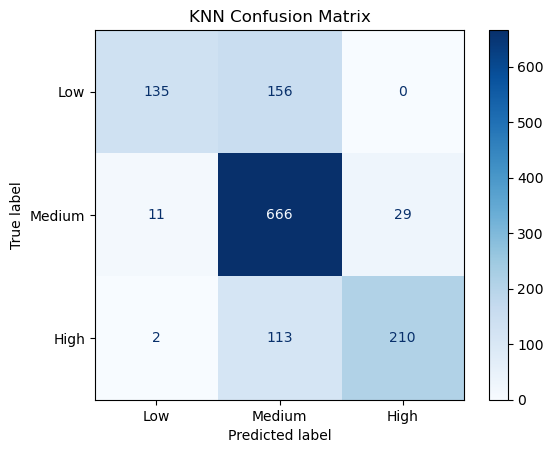

In [42]:
knn_confusion_matrix = confusion_matrix(
    y_test,
    y_pred,
    labels=class_order
)

confusion_table = pd.DataFrame(
    knn_confusion_matrix,
    index=[f"Actual {label}" for label in class_order],
    columns=[f"Predicted {label}" for label in class_order]
)

display(confusion_table)

ConfusionMatrixDisplay(
    confusion_matrix=knn_confusion_matrix,
    display_labels=class_order
).plot(cmap="Blues", values_format="d")

plt.title("KNN Confusion Matrix")
plt.grid(False)
plt.show()

In [43]:
print("Baseline accuracy:", baseline_accuracy)
print("Final KNN accuracy:", test_accuracy)
print("Accuracy improvement over baseline:", test_accuracy - baseline_accuracy)

print()
print("Baseline balanced accuracy:", baseline_balanced_accuracy)
print("Final KNN balanced accuracy:", test_balanced_accuracy)
print(
    "Balanced-accuracy improvement over baseline:",
    test_balanced_accuracy - baseline_balanced_accuracy
)

Baseline accuracy: 0.5340393343419062
Final KNN accuracy: 0.764750378214826
Accuracy improvement over baseline: 0.23071104387291985

Baseline balanced accuracy: 0.3333333333333333
Final KNN balanced accuracy: 0.684471382710336
Balanced-accuracy improvement over baseline: 0.3511380493770027


## 10. Result interpretation

### Performance summary

| Metric | Result |
|---|---:|
| KNN accuracy | 76.48% |
| Baseline accuracy | 53.40% |
| Accuracy improvement | 23.07 percentage points |
| KNN balanced accuracy | 68.45% |
| Baseline balanced accuracy | 33.33% |
| Test macro F1 | 72.38% |
| Cross-validation macro F1 | 72.25% |

The optimized KNN model clearly outperformed the majority-class baseline. The test macro F1 was also close to the cross-validation macro F1, indicating reasonably consistent performance on unseen data.

### Class-level findings

- **Strongest recall:** Medium (`94.33%`)
- **Weakest recall:** Low (`46.39%`)
- **Most common error:** 156 Low students were predicted as Medium.
- **Second most common error:** 113 High students were predicted as Medium.

These errors show that the model tends to classify uncertain cases as Medium, which is the largest class in the dataset. The findings apply specifically to this dataset, target definition, preprocessing pipeline, cross-validation design, and held-out 20% test set.
